In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os

In [7]:
# seed for reproductibily
tf.random.set_seed(42)
np.random.seed(42)

In [8]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)

GPU Available: []
TensorFlow version: 2.16.2


In [9]:
data_dir = pathlib.Path("Downloads/gtos-mobile")

In [10]:
print(data_dir.exists())

True


In [11]:
print("Checking directory structure...")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

Checking directory structure...


In [12]:
if not train_dir.exists() or not test_dir.exists():
    print("Error: train or test directory not found!")
    exit()

In [13]:
# List all classes
class_names = [item.name for item in train_dir.iterdir() if item.is_dir()]
print("Found classes:", class_names)

Found classes: ['moss', 'pebble', 'cement', 'grass', 'soil', 'large_limestone', 'brick', 'small_limestone', 'sand']


In [14]:
# Define constants
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 20

In [20]:
# First, create the full training dataset (without validation split)
print("Creating full dataset...")
full_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=None,  # No split initially
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

Creating full dataset...
Found 34227 files belonging to 9 classes.


In [21]:
# Calculate how many batches to take for 60% of data (reducing by 40%)
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
reduced_batches = int(total_batches * 0.6)  # Keep 60%, reduce by 40%

In [22]:
# Create the reduced training dataset
train_ds = full_ds.take(reduced_batches)


In [23]:
# Now create validation dataset from the remaining data
print("Creating validation dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,  # Standard validation split
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

Creating validation dataset...
Found 34227 files belonging to 9 classes.
Using 6845 files for validation.


In [24]:
# Also reduce validation set by 40%
total_val_batches = tf.data.experimental.cardinality(val_ds).numpy()
reduced_val_batches = int(total_val_batches * 0.6)  # Keep 60%, reduce by 40%
val_ds = val_ds.take(reduced_val_batches)

In [25]:
print(f"Reduced training batches: {reduced_batches}")
print(f"Reduced validation batches: {reduced_val_batches}")

Reduced training batches: 642
Reduced validation batches: 128


In [27]:
len(val_ds)

128

In [28]:
# batch size is 32 

In [29]:
print("Creating test dataset...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False  # Usually we don't shuffle test data
)

# Check the test dataset
print("Test dataset info:")
for images, labels in test_ds.take(1):
    print(f"Test batch images shape: {images.shape}")
    print(f"Test batch labels shape: {labels.shape}")
    print(f"Number of photos in test batch: {images.shape[0]}")

# Check total test batches and photos
total_test_batches = tf.data.experimental.cardinality(test_ds).numpy()
print(f"Total number of test batches: {total_test_batches}")

total_test_photos = 0
for images, labels in test_ds:
    total_test_photos += images.shape[0]
print(f"Total number of test photos: {total_test_photos}")

# Also check the class names to ensure they match training
print("Test class names:", test_ds.class_names)

Creating test dataset...
Found 1895 files belonging to 9 classes.
Test dataset info:
Test batch images shape: (32, 150, 150, 3)
Test batch labels shape: (32, 9)
Number of photos in test batch: 32
Total number of test batches: 60


2025-09-13 11:49:30.643996: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total number of test photos: 1895
Test class names: ['brick', 'cement', 'grass', 'large_limestone', 'moss', 'pebble', 'sand', 'small_limestone', 'soil']


2025-09-13 11:49:31.295751: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [31]:
# Data augmentation to improve model generalization
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [35]:
# Build a smaller CNN model
def create_model():
    model = keras.Sequential([
        # Data augmentation
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        data_augmentation,
        
        # First convolutional block
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        # Third convolutional block
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        # Use GlobalAveragePooling instead of Flatten to reduce parameters
        layers.GlobalAveragePooling2D(),
        
        # Smaller dense layer
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation='softmax')
    ])
    
    return model

# Create and compile the model
model = create_model()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,329 (438.79 KB)

 Trainable params: 111,625 (436.04 KB)

 Non-trainable params: 704 (2.75 KB)

In [36]:
# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.0001
    )
]

In [37]:
# Train the model
print("Training the model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Training the model...
Epoch 1/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 402s 624ms/step - accuracy: 0.5059 - loss: 1.4738 - val_accuracy: 0.4617 - val_loss: 1.4924 - learning_rate: 0.0010
Epoch 2/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 406s 633ms/step - accuracy: 0.6808 - loss: 0.8563 - val_accuracy: 0.7417 - val_loss: 0.6340 - learning_rate: 0.0010
Epoch 3/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 417s 650ms/step - accuracy: 0.7355 - loss: 0.6949 - val_accuracy: 0.6877 - val_loss: 0.8273 - learning_rate: 0.0010
Epoch 4/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 328s 511ms/step - accuracy: 0.7673 - loss: 0.6054 - val_accuracy: 0.7822 - val_loss: 0.5943 - learning_rate: 0.0010
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 343s 533ms/step - accuracy: 0.7962 - loss: 0.5483 - val_accuracy: 0.7615 - val_loss: 0.6502 - learning_rate: 0.0010
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 328s 511ms/step - accuracy: 0.8126 - loss: 0.4952 - val_accuracy: 0.8254 - val_loss: 0.4764 - learning_rate: 0.0010
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 32

In [38]:
# Evaluate the model on test data
print("Evaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Test loss: {test_loss:.4f}")

Evaluating on test data...
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6280 - loss: 2.1023
Test accuracy: 53.77%
Test loss: 3.0085


In [45]:
# Make predictions on sample test images
def predict_sample_images(dataset, model, class_names, num_samples=6):
    plt.figure(figsize=(15, 12))
    
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(2, 3, i+1)
            
            # Make prediction
            img_array = tf.expand_dims(images[i], 0)
            predictions = model.predict(img_array, verbose=0)
            predicted_class = class_names[np.argmax(predictions[0])]
            confidence = np.max(predictions[0])
            actual_class = class_names[np.argmax(labels[i])]
            
            # Display image
            plt.imshow(images[i].numpy().astype("uint8"))
            color = "green" if predicted_class == actual_class else "red"
            plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2%}", color=color)
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()



In [43]:
# Install scikit-learn
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 1.1 MB/s eta 0:00:0000:0100:010m

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [44]:
# Print classification report
from sklearn.metrics import classification_report

def print_classification_report(dataset, model, class_names):
    y_pred = []
    y_true = []
    
    for images, labels in dataset:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        predictions = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

print_classification_report(test_ds, model, class_names)

Classification Report:
                 precision    recall  f1-score   support

          brick       1.00      0.61      0.76       458
         cement       0.28      1.00      0.44       172
          grass       0.36      0.50      0.42       195
large_limestone       0.00      0.00      0.00        85
           moss       0.00      0.00      0.00       174
         pebble       0.52      1.00      0.69       254
           sand       0.00      0.00      0.00        93
small_limestone       0.82      0.42      0.56       309
           soil       1.00      0.57      0.72       155

       accuracy                           0.54      1895
      macro avg       0.44      0.45      0.40      1895
   weighted avg       0.59      0.54      0.51      1895



2025-09-13 18:02:35.075893: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: Unde

In [46]:
def predict_new_image(image_path, model, class_names):
    """
    Predict the class of a new image and return the prediction with confidence score.
    
    Parameters:
    image_path (str): Path to the image file
    model: Trained TensorFlow model
    class_names: List of class names
    
    Returns:
    tuple: (predicted_class, confidence_score, all_predictions)
    """
    # Load and preprocess the image
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension
    
    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence_score = predictions[0][predicted_class_idx]
    
    # Get all class probabilities
    all_predictions = {class_names[i]: float(predictions[0][i]) for i in range(len(class_names))}
    
    return predicted_class, confidence_score, all_predictions

# Function to display prediction with image
def display_prediction(image_path, model, class_names):
    """
    Display the image along with prediction and confidence score.
    """
    # Get prediction
    predicted_class, confidence, all_predictions = predict_new_image(image_path, model, class_names)
    
    # Load and display image
    img = plt.imread(image_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}", fontsize=14, pad=20)
    plt.show()
    
    # Print detailed predictions
    print("Detailed predictions:")
    for class_name, prob in sorted(all_predictions.items(), key=lambda x: x[1], reverse=True):
        print(f"{class_name}: {prob:.2%}")
    
    return predicted_class, confidence

In [48]:
# above functions can be used to make predictions and also get confidence score at the same time

In [49]:
# Example 1: Simple prediction
#image_path = "path/to/your/image.jpg"
#predicted_class, confidence, all_predictions = predict_new_image(image_path, model, class_names)
#print(f"Predicted: {predicted_class} with {confidence:.2%} confidence")

# Example 2: Display prediction with image
#image_path = "path/to/your/image.jpg"
#predicted_class, confidence = display_prediction(image_path, model, class_names)



# can be used in this way

Actual class: grass


2025-09-13 18:21:13.480588: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


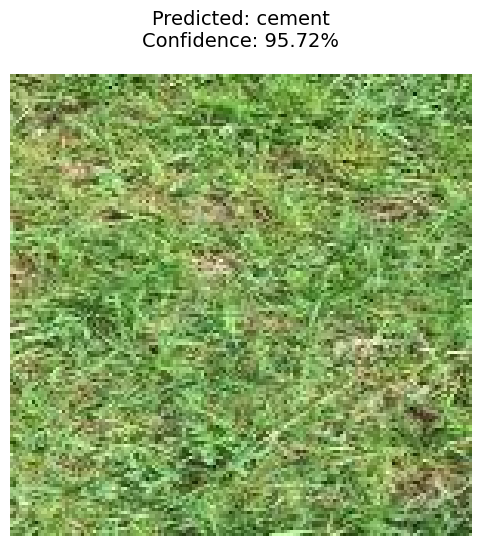

Detailed predictions:
cement: 95.72%
grass: 4.28%
sand: 0.00%
pebble: 0.00%
moss: 0.00%
small_limestone: 0.00%
large_limestone: 0.00%
soil: 0.00%
brick: 0.00%


In [79]:
import random

# Convert test dataset to list and shuffle to get random image
test_images_list = list(test_ds.unbatch().shuffle(1000))

# Select a random image
random_image, random_label = random.choice(test_images_list)

# Get the actual class name
actual_class = class_names[np.argmax(random_label)]

# Save it temporarily to test our function
temp_path = "temp_test_image.jpg"
plt.imsave(temp_path, random_image.numpy().astype('uint8'))

# Test our prediction function
print(f"Actual class: {actual_class}")
predicted_class, confidence = display_prediction(temp_path, model, class_names)

# Clean up
import os
os.remove(temp_path)